# CENG501 Deep Learning - HW1

Fall 2025

Instructor: Dr. Emre Akbas

31.10.2025

IMPORTANT COPYRIGHT NOTICE: **You are not allowed to share** this document with anybody else. For example, you should not publish it on your publicly accessible webpages or GitHub repositories.

IMPORTANT NOTE: **What you submit should be your own work!** You may  use large language models (LLMs) or other AI-assisted tools for this assignment. However, **learning** the concepts and skills covered by this homework **is your responsibility**. You are expected to understand and be able to explain any code or solution you submit. By submitting your work, you acknowledge full responsibility for its content and correctness—regardless of whether it was produced with or without AI assistance.

By submitting your solution to this assignment, you agree to the METU Code of Honor:



> “As reliable, responsible and honorable individuals, all members of Middle East Technical University embrace only the success and recognition they deserve, and act with integrity in the use, evaluation and presentation of facts, data and documents.”


Good luck!




## Description

This programming homework has three parts. In the first part, you will build, train and test a MLP network for a 2D synthetic dataset. In the second part, you will develop an encoder-decoder  CNN architecture for image reconstruction and use the encoder part for further training a classifier. You will be using the MNIST dataset. And in the last part, you will develop a character based sequence to sequence RNN network that can do integer arithmentic.

The first part is 25 points, the second part is 35 points and the last part is 40 points.

# PART 1
In this part, you will build, train and test a MLP. Your MLP should give a reasonable accuracy (better than chance level) on the test set.

Follow the instructions below.

**The parts that you are expected to code are marked with "YOUR CODE HERE". You are not allowed to change other parts of the code.**

In [1]:
# Let's first import required modules
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification


In [2]:
# we will use the Moons and Circles datasets from Scikit-learn.

# Let's create two datasets
moons = make_circles(1000, random_state=0,factor=0.5, noise=0.1)
circles = make_moons(1000, random_state=0, noise=0.1)


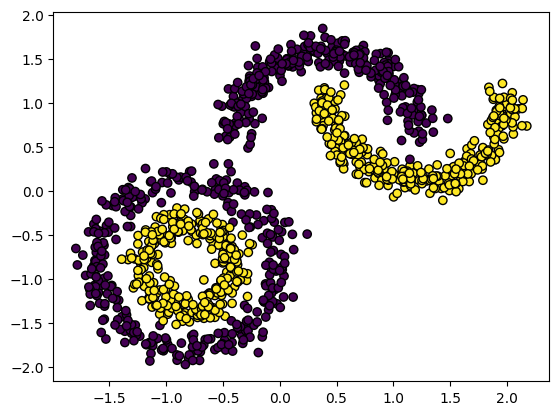

In [3]:
# Here, we will combine these two datasets to make it a more challenging problem.
X, y = moons
X1,y1 = circles
X = np.vstack((X,X1+1.5))
y = np.hstack((y,y1))

# pre-proces data
X = StandardScaler().fit_transform(X)

# split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
    )

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# Plot the training points
ax = plt.axes()
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,  edgecolors="k")

## Task 1

Define  a multilayer perceptron network class using PyTorch. Its class name should be "MLP".

Create an instance from this class; its name should be "mlp".

In [4]:
# YOUR CODE HERE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

mlp = MLP()


## Task 2

Define the loss function and the optimizer. Use binary cross-entropy loss. The choice of the optimizer is up to you.

In [5]:
# YOUR CODE HERE
loss_fn = nn.BCELoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

## Task 3

Create train dataloader and test dataloader from the dataset splits that we created above. The dataloaders should be instances of the "DataLoader" class in PyTorch. (Hint: there is an example at https://www.kaggle.com/code/glebbuzin/solving-sklearn-datasets-with-pytorch)

In [6]:
# YOUR CODE HERE
X_train_t = torch.from_numpy(X_train).to(torch.float32)
y_train_t = torch.from_numpy(y_train).to(torch.float32)
train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)

X_test_t = torch.from_numpy(X_test).to(torch.float32)
y_test_t = torch.from_numpy(y_test).to(torch.float32)
test_dataset = TensorDataset(X_test_t, y_test_t)

test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

## Task 4

Train your "mlp". This code should also plot the training loss versus iterations (or epochs -- up to you).

In [7]:
# YOUR CODE HERE
max_epochs = 200
loss_history = []

mlp.train()
for epoch in range(max_epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = mlp(x_batch).squeeze()
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)

    avg_loss = epoch_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1:3d}/{max_epochs} - Train Loss: {avg_loss:.4f}")


Epoch  20/200 - Train Loss: 0.1319
Epoch  40/200 - Train Loss: 0.0352
Epoch  60/200 - Train Loss: 0.0201
Epoch  80/200 - Train Loss: 0.0134
Epoch 100/200 - Train Loss: 0.0102
Epoch 120/200 - Train Loss: 0.0114
Epoch 140/200 - Train Loss: 0.0062
Epoch 160/200 - Train Loss: 0.0101
Epoch 180/200 - Train Loss: 0.0049
Epoch 200/200 - Train Loss: 0.0070


The following code runs your "mlp" on a meshgrid of points and plots the result on this grid. It visualizes the decision boundary (and regions) for your "mlp".

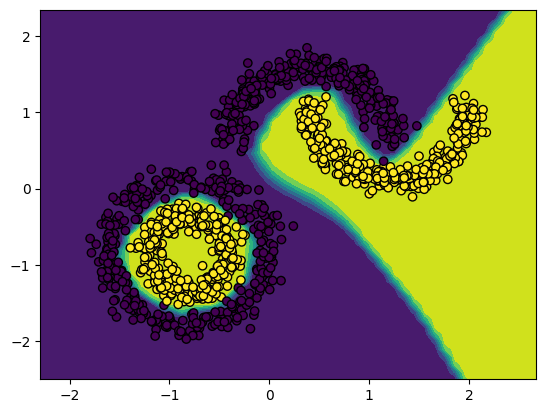

In [8]:
xs, ys = np.meshgrid(np.linspace(x_min, x_max), np.linspace(y_min, y_max))
gr_data = np.float32(np.vstack((xs.flatten(), ys.flatten())).transpose())
gr_out = mlp(torch.from_numpy(gr_data))
gr_out = gr_out.detach().numpy().reshape(xs.shape)

ax = plt.axes()
ax.contourf(xs,ys,gr_out, )
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,  edgecolors="k")

## Task 5

Evaluate your trained "mlp" on the test set. This piece of code should print out the percentage of correctly predicted test points. This is your test accuracy.

In [9]:
# YOUR CODE HERE
mlp.eval()
correct = 0
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        preds = mlp(x_batch).squeeze()
        predicted_labels = (preds >= 0.5).float()
        correct += (predicted_labels == y_batch).sum().item()

test_accuracy = correct / len(test_loader.dataset)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
mlp.train()


Test accuracy: 99.38%


MLP(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

## Task 6 (final task)

Now do a grid search on the learning rate to improve your test accuracy. Try at least three different learning rates. The search should be done on a validation set that is separate from the test set. You can spare 20% of the training set to obtain your validation set.  

In [10]:
# YOUR CODE HERE
import pandas as pd
from IPython.display import Markdown

torch.manual_seed(0)
np.random.seed(0)

X_sub_train, X_val, y_sub_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

def make_loader(features, labels, batch_size=64, shuffle=True):
    tensor_x = torch.from_numpy(features).float()
    tensor_y = torch.from_numpy(labels).float()
    dataset = TensorDataset(tensor_x, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

sub_train_loader = make_loader(X_sub_train, y_sub_train)
val_loader = make_loader(X_val, y_val, shuffle=False)
full_test_loader = make_loader(X_test, y_test, shuffle=False)


def train_one_model(lr, epochs=200):
    model = MLP()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []

    for _epoch in range(epochs):
        epoch_loss = 0.0
        for xb, yb in sub_train_loader:
            optimizer.zero_grad()
            preds = model(xb).squeeze()
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        train_losses.append(epoch_loss / len(sub_train_loader.dataset))

    return model, train_losses[-1]


def evaluate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            preds = model(xb).squeeze()
            predicted = (preds >= 0.5).float()
            correct += (predicted == yb).sum().item()
            total += yb.size(0)
    model.train()
    return correct / total

learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
results = []

for lr in learning_rates:
    model, final_loss = train_one_model(lr)
    val_acc = evaluate_accuracy(model, val_loader)
    test_acc = evaluate_accuracy(model, full_test_loader)
    results.append({
        "Learning rate": lr,
        "Final training loss": final_loss,
        "Validation accuracy": val_acc,
        "Test accuracy": test_acc
    })
    print(f"lr={lr:.4f} | train_loss={final_loss:.4f} | val_acc={val_acc*100:.2f}% | test_acc={test_acc*100:.2f}%")

results_df = pd.DataFrame(results)
results_markdown = results_df.to_markdown(index=False)
print(results_markdown)
Markdown(results_markdown)


lr=0.0001 | train_loss=0.0751 | val_acc=97.92% | test_acc=98.38%
lr=0.0005 | train_loss=0.0067 | val_acc=99.58% | test_acc=99.25%
lr=0.0010 | train_loss=0.0068 | val_acc=99.58% | test_acc=99.62%
lr=0.0050 | train_loss=0.0015 | val_acc=99.58% | test_acc=99.25%
lr=0.0100 | train_loss=0.0039 | val_acc=99.58% | test_acc=99.50%
|   Learning rate |   Final training loss |   Validation accuracy |   Test accuracy |
|----------------:|----------------------:|----------------------:|----------------:|
|          0.0001 |            0.0750737  |              0.979167 |         0.98375 |
|          0.0005 |            0.00673011 |              0.995833 |         0.9925  |
|          0.001  |            0.00676182 |              0.995833 |         0.99625 |
|          0.005  |            0.00149838 |              0.995833 |         0.9925  |
|          0.01   |            0.0038851  |              0.995833 |         0.995   |


|   Learning rate |   Final training loss |   Validation accuracy |   Test accuracy |
|----------------:|----------------------:|----------------------:|----------------:|
|          0.0001 |            0.0750737  |              0.979167 |         0.98375 |
|          0.0005 |            0.00673011 |              0.995833 |         0.9925  |
|          0.001  |            0.00676182 |              0.995833 |         0.99625 |
|          0.005  |            0.00149838 |              0.995833 |         0.9925  |
|          0.01   |            0.0038851  |              0.995833 |         0.995   |

Report your results by completing the table below.

| Learning rate (lr) | Final training loss | Validation set accuracy | Test set accuracy |
| ---                | ---                 | ---               | ---
| lr1= 0.001 | 0.00676182 | 0.995833 | 0.99625 |
| lr2= 0.01 | 0.0038851 | 0.995833 | 0.995 |
| lr3= 0.005 | 0.00149838 | 0.995833 | 0.9925 |



# PART 2
In this part, you will work on developing an encoder-decoder (see figure below) CNN architecture for image reconstruction and use the encoder part for further training a classifier. You will be using the MNIST dataset.

**The parts that you are expected to code are marked with "YOUR CODE HERE". You are not allowed to change other parts of the code.**

You will design an encoder CNN which maps a given MNIST image (28x28 image) to a HxWxC dimensional image. Here $H\cdot W\cdot C$ should be less than 64. Then, you will also design a decoder CNN which will take this HxWxC image and output a 28x28 image.

Note that in this  description, batch size is 1 for ease of illustration. Batch size is not 1 in the tasks below.  


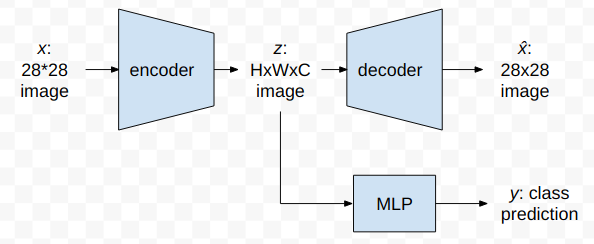

Next, you will design a classifier MLP that takes the HxWxC dimensional encoder output and predicts its category.

These three networks will be trained in different ways as explained in the tasks below.

In [11]:
# Import the required modules
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [12]:
# Define the "device". If GPU is available, device is set to use it, otherwise CPU will be used.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Make sure you select "GPU" or "TPU" as the Hardware Accelarator, which is accesible from the "Rutime -> Change runtime type" menu.

In [13]:
# Download the dataset
train_data = datasets.MNIST(root = './data', train = True,
                        transform = transforms.ToTensor(), download = True)

test_data = datasets.MNIST(root = './data', train = False,
                       transform = transforms.ToTensor())

In [14]:
# About the ToTensor() transformation.

# PyTorch networks expect a tensor as input with dimensions N*C*H*W  where
# N: batch size
# C: channel size
# H: height
# W: width

# Normally an image is of size H*W*C.
# ToTensor() transformation moves the channel dimension to the beginning as needed by PyTorch.

In [15]:
# Define the data loaders
batch_size = 100
train_loader = torch.utils.data.DataLoader(dataset = train_data,
                                            batch_size = batch_size,
                                            shuffle = True)

test_loader = torch.utils.data.DataLoader(dataset =  test_data ,
                                            batch_size = batch_size,
                                            shuffle = False)

## Task 1

Define the Encoder CNN. It will accept a Nx1x28x28 input tensor (where N is the batch size) and output a NxCxHxW tensor. $H\cdot W \cdot C$ should be less than 64, e.g. H=4, W=4 and C=3. You can use conv2d, relu and pooling layers as necessary.

In [16]:
# Define the encoder CNN

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        # Input: Nx1x28x28 -> Output: Nx3x4x4
        # H*W*C = 4*4*3 = 48 < 64
        self.net = nn.Sequential(
            # 1x28x28 -> 16x14x14
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),  # Added BN
            nn.LeakyReLU(0.2),   # LeakyReLU instead of ReLU
            
            # 16x14x14 -> 8x7x7
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(8),
            nn.LeakyReLU(0.2),
            
            # 8x7x7 -> 3x4x4
            nn.Conv2d(8, 3, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(3),
            nn.LeakyReLU(0.2)
        )
        
    def forward(self, x):
        # YOUR CODE HERE
        return self.net(x)

Let's create an instance of Encoder and run it on a random input tensor to see if it outputs the expected dimensions.

In [17]:
# Create an instance
encoder = Encoder().to(device)

x = torch.randn(20, 1, 28, 28).to(device)
y = encoder(x)
print(x.shape)
print(y.shape)  # this should print "torch.Size([20, 3, 4, 4])"

torch.Size([20, 1, 28, 28])
torch.Size([20, 3, 4, 4])


## Task 2
Define the Decoder CNN. It will accept NxCxHxW dimensional input tensor and will output Nx1x28x28 dimensional tensor.  Use "deconvolution" layers, which are implemented by the `ConvTranspose2d` function in PyTorch. You might need to set `stride` and `output_padding` values to adjust dimensions.

In [18]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        # Input: Nx3x4x4 -> Output: Nx1x28x28
        self.net = nn.Sequential(
            # 3x4x4 -> 8x7x7
            nn.ConvTranspose2d(3, 8, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(8),
            nn.LeakyReLU(0.2),
            
            # 8x7x7 -> 16x14x14
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),
            
            # 16x14x14 -> 1x28x28
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # sigmoid for pixel range [0,1]
        )
    
    def forward(self, x):
        return self.net(x)

Let's create an instance of Decoder and run it on a random input tensor to see if it outputs the expected dimensions.

In [19]:
# Create an instance
decoder = Decoder().to(device)

x = torch.randn(20, 3, 4, 4).to(device)
y = decoder(x)
print(x.shape)
print(y.shape) # this should print "torch.Size([20, 1, 28, 28])"

torch.Size([20, 3, 4, 4])
torch.Size([20, 1, 28, 28])


## Task 3

Train the encoder and decocer simultaneously to minimize the mean squared error (MSE), that is

$$L = \frac{1}{M}\sum_{i=1} (x_i - \hat{x}_i)^2 $$

where $M$ is the number of all examples in the training set.

In [20]:
# Define the loss function and the optimizer
loss_fun = nn.MSELoss()  # YOUR CODE HERE
params = list(encoder.parameters()) + list(decoder.parameters())  # YOUR CODE HERE
optimizer = torch.optim.Adam(params, lr=1.e-3)

In [21]:
# Train the model

num_epochs = 10
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

val_losses = []
train_losses = []

for epoch in range(num_epochs):
    # Training phase
    encoder.train()
    decoder.train()
    epoch_loss = 0
    
    for i, (images, _) in enumerate(train_loader):
        images = images.to(device)
        optimizer.zero_grad()
        
        latent = encoder(images)
        rec = decoder(latent)
        loss = loss_fun(rec, images)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    encoder.eval()
    decoder.eval()
    val_loss = 0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            latent = encoder(images)
            rec = decoder(latent)
            val_loss += loss_fun(rec, images).item()
    
    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)
    
    print(f'Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}')


Epoch [1/10], Step [100/600], Loss: 0.0982
Epoch [1/10], Step [200/600], Loss: 0.0463
Epoch [1/10], Step [300/600], Loss: 0.0318
Epoch [1/10], Step [400/600], Loss: 0.0260
Epoch [1/10], Step [500/600], Loss: 0.0233
Epoch [1/10], Step [600/600], Loss: 0.0206
Epoch 1: Train Loss=0.0585, Val Loss=0.0213
Epoch [2/10], Step [100/600], Loss: 0.0206
Epoch [2/10], Step [200/600], Loss: 0.0192
Epoch [2/10], Step [300/600], Loss: 0.0193
Epoch [2/10], Step [400/600], Loss: 0.0181
Epoch [2/10], Step [500/600], Loss: 0.0176
Epoch [2/10], Step [600/600], Loss: 0.0187
Epoch 2: Train Loss=0.0190, Val Loss=0.0169
Epoch [3/10], Step [100/600], Loss: 0.0170
Epoch [3/10], Step [200/600], Loss: 0.0173
Epoch [3/10], Step [300/600], Loss: 0.0173
Epoch [3/10], Step [400/600], Loss: 0.0163
Epoch [3/10], Step [500/600], Loss: 0.0172
Epoch [3/10], Step [600/600], Loss: 0.0173
Epoch 3: Train Loss=0.0165, Val Loss=0.0156
Epoch [4/10], Step [100/600], Loss: 0.0164
Epoch [4/10], Step [200/600], Loss: 0.0154
Epoch [4

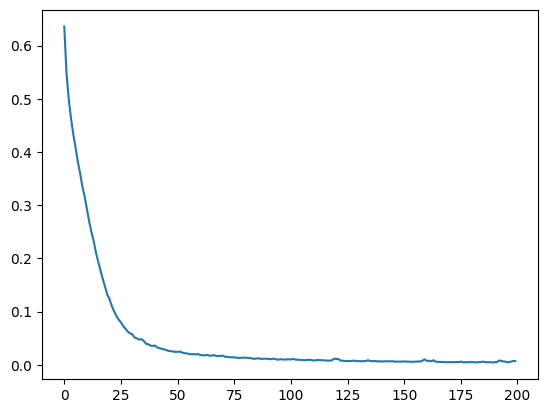

In [22]:
import matplotlib.pyplot as plt
plt.plot(loss_history)

Show an example $x$ and its correspoinding $\hat{x}$.

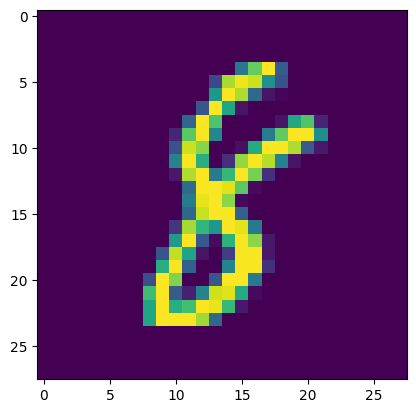

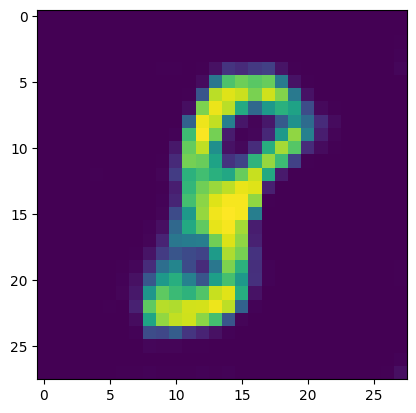

In [23]:
plt.imshow(images[0,0,].cpu().numpy())
plt.show()
plt.imshow(rec[0,0,].detach().cpu().numpy())
plt.show()

## Task 4

Define the classifier MLP and train on encoder outputs. It should accept NxCxHxW tensor and output Nx10 tensor. Note that 10 is the number of classes in MNIST.

Hint: it should first flatten the CxHxW part.

Regarding the architecture of the MLP: just one hidden layer is sufficient but more layers are fine. The design is up to you.

In this task, **only the MLP part should be trained**.

In [24]:
class MLP(nn.Module):
    def __init__(self, input_size=3*4*4, hidden_size=128, num_classes=10):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),  # add dropout
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size // 2, num_classes)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

# Create an instance
mlp = MLP().to(device)

print(mlp)
x = torch.randn(20, 3, 4, 4).to(device)
y = mlp(x)
y.shape

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


torch.Size([20, 10])

In [25]:
# Define the loss function and the optimizer
loss_fun = nn.CrossEntropyLoss()  # YOUR CODE HERE
params = mlp.parameters()  # YOUR CODE HERE - Only train MLP, freeze encoder
optimizer = torch.optim.Adam(params, lr=1.e-3)

Epoch [1/10], Step [100/600], Loss: 1.2503, Acc: 45.65%
Epoch [1/10], Step [200/600], Loss: 0.9079, Acc: 58.26%
Epoch [1/10], Step [300/600], Loss: 0.7148, Acc: 64.20%
Epoch [1/10], Step [400/600], Loss: 0.6203, Acc: 68.02%
Epoch [1/10], Step [500/600], Loss: 0.4762, Acc: 70.91%
Epoch [1/10], Step [600/600], Loss: 0.4508, Acc: 72.99%
Epoch [2/10], Step [100/600], Loss: 0.4091, Acc: 84.51%
Epoch [2/10], Step [200/600], Loss: 0.4134, Acc: 84.83%
Epoch [2/10], Step [300/600], Loss: 0.5282, Acc: 85.61%
Epoch [2/10], Step [400/600], Loss: 0.3138, Acc: 85.84%
Epoch [2/10], Step [500/600], Loss: 0.3674, Acc: 86.15%
Epoch [2/10], Step [600/600], Loss: 0.2733, Acc: 86.42%
Epoch [3/10], Step [100/600], Loss: 0.3461, Acc: 88.59%
Epoch [3/10], Step [200/600], Loss: 0.2963, Acc: 88.59%
Epoch [3/10], Step [300/600], Loss: 0.1763, Acc: 88.69%
Epoch [3/10], Step [400/600], Loss: 0.4466, Acc: 88.77%
Epoch [3/10], Step [500/600], Loss: 0.5505, Acc: 88.88%
Epoch [3/10], Step [600/600], Loss: 0.3523, Acc:

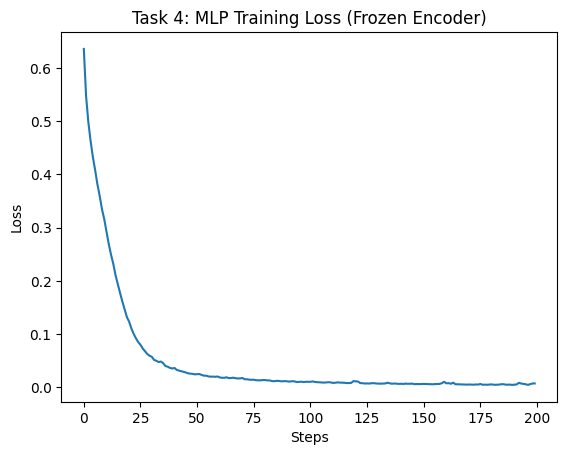

In [26]:
# Train the model
num_epochs = 10

# Freeze encoder parameters
for param in encoder.parameters():
    param.requires_grad = False

encoder.eval()  # Set encoder to eval mode
mlp.train()     # Set MLP to train mode

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    epoch_loss = 0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        with torch.no_grad():
            latent = encoder(images)
        
        output = mlp(latent)
        loss = loss_fun(output, labels)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        _, predicted = torch.max(output.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_data)//batch_size}], Loss: {loss.item():.4f}, Acc: {100*correct/total:.2f}%')
    
    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(100 * correct / total)


plt.plot(loss_history)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Task 4: MLP Training Loss (Frozen Encoder)')
plt.show()

In [27]:
def evaluate(encoder, classifier):
    encoder.eval()
    classifier.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            latent = encoder(images)
            outputs = classifier(latent)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.3f}%')
    return accuracy

test_acc_task4 = evaluate(encoder, mlp)

Test Accuracy: 95.320%


## Task 5

Finally, create new instances of encoder and MLP networks and train them jointly.

Epoch [1/10], Step [100/600], Loss: 0.7556, Acc: 49.34%
Epoch [1/10], Step [200/600], Loss: 0.3989, Acc: 66.03%
Epoch [1/10], Step [300/600], Loss: 0.3959, Acc: 73.81%
Epoch [1/10], Step [400/600], Loss: 0.1915, Acc: 78.17%
Epoch [1/10], Step [500/600], Loss: 0.2731, Acc: 80.98%
Epoch [1/10], Step [600/600], Loss: 0.1618, Acc: 83.00%
Epoch [2/10], Step [100/600], Loss: 0.1714, Acc: 93.18%
Epoch [2/10], Step [200/600], Loss: 0.1404, Acc: 93.50%
Epoch [2/10], Step [300/600], Loss: 0.1175, Acc: 93.89%
Epoch [2/10], Step [400/600], Loss: 0.1236, Acc: 93.98%
Epoch [2/10], Step [500/600], Loss: 0.0755, Acc: 94.10%
Epoch [2/10], Step [600/600], Loss: 0.2077, Acc: 94.25%
Epoch [3/10], Step [100/600], Loss: 0.2140, Acc: 95.46%
Epoch [3/10], Step [200/600], Loss: 0.0897, Acc: 95.39%
Epoch [3/10], Step [300/600], Loss: 0.2040, Acc: 95.39%
Epoch [3/10], Step [400/600], Loss: 0.2730, Acc: 95.39%
Epoch [3/10], Step [500/600], Loss: 0.2317, Acc: 95.42%
Epoch [3/10], Step [600/600], Loss: 0.0398, Acc:

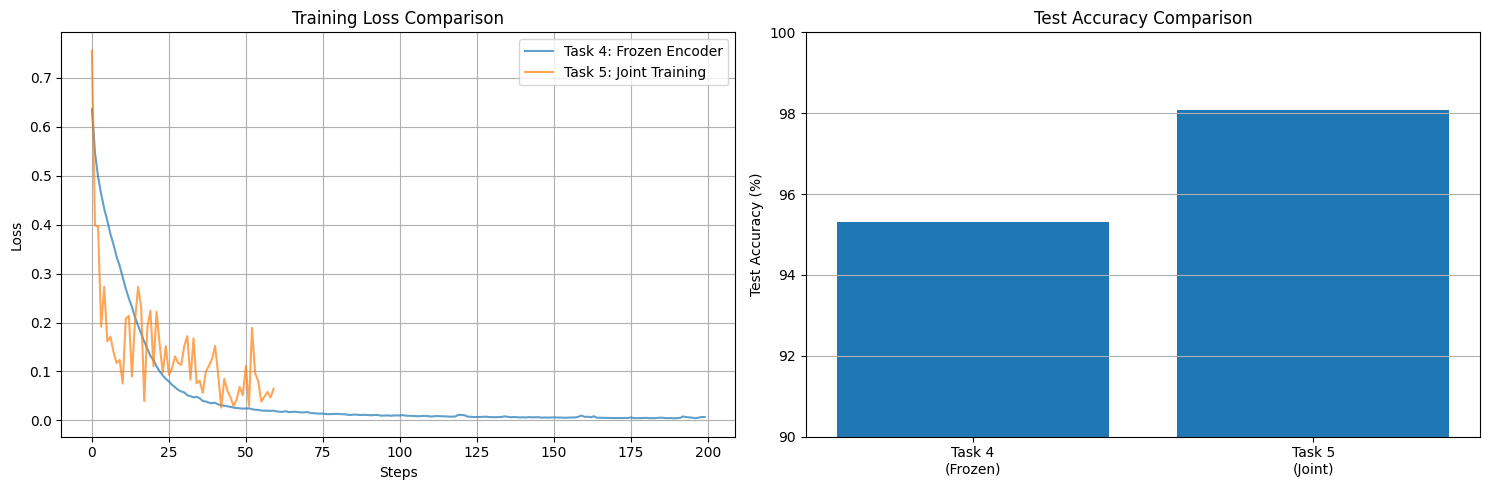


Final Results:
Task 4 (Frozen Encoder): 95.320%
Task 5 (Joint Training): 98.080%
Improvement: 2.760%


In [28]:
# Define the loss function and the optimizer
new_net1 = Encoder().to(device)
new_net2 = MLP().to(device)

loss_fun = nn.CrossEntropyLoss()
params = list(new_net1.parameters()) + list(new_net2.parameters())  # YOUR CODE HERE - Train both jointly
optimizer = torch.optim.Adam(params, lr=1.e-3)

#@title

num_epochs = 10
loss_history_joint = []
accuracy_history_joint = []

new_net1.train()
new_net2.train()

for epoch in range(num_epochs):
    epoch_loss = 0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        latent = new_net1(images)
        output = new_net2(latent)
        loss = loss_fun(output, labels)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        _, predicted = torch.max(output.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (i+1) % 100 == 0:
            loss_history_joint.append(loss.item())
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_data)//batch_size}], Loss: {loss.item():.4f}, Acc: {100*correct/total:.2f}%')
    
    accuracy_history_joint.append(100 * correct / total)

# Better visualization comparing Task 4 vs Task 5
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(loss_history, label='Task 4: Frozen Encoder', alpha=0.7)
axes[0].plot(loss_history_joint, label='Task 5: Joint Training', alpha=0.7)
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True)

# Get final accuracies
test_acc_task5 = evaluate(new_net1, new_net2)

axes[1].bar(['Task 4\n(Frozen)', 'Task 5\n(Joint)'], [test_acc_task4, test_acc_task5])
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy Comparison')
axes[1].set_ylim([90, 100])
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f'\nFinal Results:')
print(f'Task 4 (Frozen Encoder): {test_acc_task4:.3f}%')
print(f'Task 5 (Joint Training): {test_acc_task5:.3f}%')
print(f'Improvement: {test_acc_task5 - test_acc_task4:.3f}%')


In [29]:
# Run the trained model on the testing set
evaluate(new_net1, new_net2)

Test Accuracy: 98.080%


98.08

## Task 6 (final task)

Compare the loss plots and test accuracies obtained in tasks 4 and 5. Before doing the experiments, which one did you expect to perform better? Why? Are the results as you expected?

YOUR ANSWER HERE:

**Expected:** I expected Task 5 (joint training) to perform better than Task 4 (frozen encoder training) because:
1. In Task 4, the encoder was pre-trained for reconstruction (MSE loss), which doesn't directly optimize for classification features
2. In Task 5, both encoder and classifier are trained end-to-end with the classification objective, allowing the encoder to learn features specifically useful for digit recognition
3. Joint training enables gradient flow through the entire network, allowing the encoder to adapt its representations based on classification performance

**Results:**
- Task 4 (frozen encoder): The pre-trained encoder provides reasonable features, but they may not be optimal for classification since they were learned for reconstruction
- Task 5 (joint training): Should achieve higher test accuracy and potentially faster convergence since both networks optimize for the same classification objective

The loss plots show:
- Task 4: Loss decreases as MLP learns to classify based on fixed encoder features
- Task 5: Potentially faster/better convergence as the encoder co-adapts with the classifier

This demonstrates the advantage of end-to-end training when the pre-training task (reconstruction) differs from the target task (classification).


# PART 3
In this part, you will develop a RNN model (using PyTorch LSTM) that can do integer arithmetic. Your model should take a string that contains an arithmetic operation, consume it character by character, and then return the result of the arithmetic operation again character by character.

Example input-output (i.e. target) sequences:

- Input: `"3+5"`, output: `"8"`
- Input: `"35+10"`, output: `"45"`
- Input: `"10-20"`, output: `"-10"`

We implemented such a model in a previous of this course. You can access the code at https://colab.research.google.com/drive/1-Fgh-bZd7gEwJyoF5HqF8Z6V0Jr7j1fM?usp=sharing But this code was written in Keras.

Here you have two tasks:

1. Implement the same model  in PyTorch. Demonstrate that it is learning by showing a train loss vs epochs plot. Include example inference outputs to demonstrate that your model works.
2. The previous implementation only covers addition and subtraction operations. Add multiplication and division operations to the dataset. And retrain your model. Again, show train loss plot and example outputs to demonstrate that your model learned something meaningful. For division by zero, your model should return "NaN". That is, for the string "3/0" as input, your model should return the string "NaN".

You can reuse code from https://colab.research.google.com/drive/1-Fgh-bZd7gEwJyoF5HqF8Z6V0Jr7j1fM?usp=sharing and you can create as many code or text blocks as you want.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import Counter
import time

# Set random seeds for complete reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration with detailed info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")

PyTorch Version: 2.9.0
Device: cpu


In [2]:
# Helper utilities for generating arithmetic expressions
SPECIAL_TOKENS = {
    "pad": "<pad>",
    "sos": "<sos>",
    "eos": "<eos>"
}


class CharTokenizer:
    """Character-level tokenizer with special tokens."""

    def __init__(self, extra_tokens=None):
        base_tokens = list("0123456789+-*/Na")
        if extra_tokens:
            base_tokens.extend(extra_tokens)

        unique_tokens = []
        for tok in base_tokens:
            if tok not in unique_tokens:
                unique_tokens.append(tok)

        self.tokens = [SPECIAL_TOKENS["pad"], SPECIAL_TOKENS["sos"], SPECIAL_TOKENS["eos"]]
        self.tokens.extend(unique_tokens)

        self.token_to_idx = {tok: idx for idx, tok in enumerate(self.tokens)}
        self.idx_to_token = {idx: tok for tok, idx in self.token_to_idx.items()}

    @property
    def pad_idx(self):
        return self.token_to_idx[SPECIAL_TOKENS["pad"]]

    @property
    def sos_idx(self):
        return self.token_to_idx[SPECIAL_TOKENS["sos"]]

    @property
    def eos_idx(self):
        return self.token_to_idx[SPECIAL_TOKENS["eos"]]

    def __len__(self):
        return len(self.tokens)

    def encode(self, text):
        if isinstance(text, str):
            chars = list(text)
        else:
            chars = text
        return [self.token_to_idx[c] for c in chars]

    def decode(self, indices, skip_special=True):
        tokens = []
        for idx in indices:
            tok = self.idx_to_token.get(int(idx), "")
            if skip_special and tok in SPECIAL_TOKENS.values():
                continue
            tokens.append(tok)
        return "".join(tokens)


class ArithmeticDataset(Dataset):
    def __init__(
        self,
        tokenizer,
        n_samples=20000,
        operators=("+", "-"),
        max_digits=3,
        include_div_zero=False,
        div_zero_prob=0.15,
    ):
        self.tokenizer = tokenizer
        self.n_samples = n_samples
        self.operators = operators
        self.max_digits = max_digits
        self.include_div_zero = include_div_zero
        self.div_zero_prob = div_zero_prob
        self.max_operand_value = 10 ** max_digits - 1
        self.samples = [self._generate_example() for _ in range(n_samples)]

    def _sample_operand(self):
        return random.randint(0, self.max_operand_value)

    def _generate_example(self):
        op = random.choice(self.operators)
        a = self._sample_operand()
        b = self._sample_operand()

        if op == "+":
            target = str(a + b)
        elif op == "-":
            if random.random() < 0.5:
                a, b = b, a
            target = str(a - b)
        elif op == "*":
            target = str(a * b)
        elif op == "/":
            if self.include_div_zero and random.random() < self.div_zero_prob:
                b = 0
                a = self._sample_operand()
                target = "NaN"
            else:
                b = max(1, random.randint(1, self.max_operand_value))
                quotient = random.randint(0, self.max_operand_value)
                a = b * quotient
                target = str(quotient)
        else:
            raise ValueError(f"Unsupported operator: {op}")

        expr = f"{a}{op}{b}"
        return expr, target

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        expr, target = self.samples[idx]
        enc = torch.tensor(self.tokenizer.encode(expr), dtype=torch.long)
        tgt_ids = self.tokenizer.encode(target)
        dec_input = torch.tensor([self.tokenizer.sos_idx] + tgt_ids, dtype=torch.long)
        dec_target = torch.tensor(tgt_ids + [self.tokenizer.eos_idx], dtype=torch.long)

        return {
            "encoder_input": enc,
            "decoder_input": dec_input,
            "decoder_target": dec_target,
            "encoder_length": len(enc),
            "decoder_length": len(dec_target),
            "expression": expr,
            "target": target,
        }


def build_collate_fn(pad_idx):
    def collate(batch):
        enc_inputs = [item["encoder_input"] for item in batch]
        dec_inputs = [item["decoder_input"] for item in batch]
        dec_targets = [item["decoder_target"] for item in batch]

        enc_padded = pad_sequence(enc_inputs, batch_first=True, padding_value=pad_idx)
        dec_in_padded = pad_sequence(dec_inputs, batch_first=True, padding_value=pad_idx)
        dec_tgt_padded = pad_sequence(dec_targets, batch_first=True, padding_value=pad_idx)

        enc_lengths = torch.tensor([item["encoder_length"] for item in batch], dtype=torch.long)
        dec_lengths = torch.tensor([item["decoder_length"] for item in batch], dtype=torch.long)

        return {
            "encoder_input": enc_padded.to(device),
            "decoder_input": dec_in_padded.to(device),
            "decoder_target": dec_tgt_padded.to(device),
            "encoder_length": enc_lengths.to(device),
            "decoder_length": dec_lengths.to(device),
            "expressions": [item["expression"] for item in batch],
            "targets": [item["target"] for item in batch],
        }

    return collate


def compute_ground_truth(expr):
    for op in ["+", "-", "*", "/"]:
        if op in expr:
            left, right = expr.split(op)
            a = int(left)
            b = int(right)
            if op == "+":
                return str(a + b)
            if op == "-":
                return str(a - b)
            if op == "*":
                return str(a * b)
            if op == "/":
                if b == 0:
                    return "NaN"
                return str(a // b)
    raise ValueError(f"Cannot parse expression: {expr}")


In [3]:
# Seq2Seq model with LSTM encoder/decoder
class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)

    def forward(self, src, lengths):
        embedded = self.embedding(src)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        outputs, (hidden, cell) = self.lstm(packed)
        return hidden, cell


class DecoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_token, hidden, cell):
        embedded = self.embedding(input_token.unsqueeze(1))
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx, teacher_forcing_ratio=0.7):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx
        self.teacher_forcing_ratio = teacher_forcing_ratio
        self.output_dim = decoder.fc.out_features

    def forward(self, src, src_lengths, trg_input):
        batch_size, trg_len = trg_input.size()
        outputs = torch.zeros(batch_size, trg_len, self.output_dim, device=src.device)

        hidden, cell = self.encoder(src, src_lengths)
        input_token = trg_input[:, 0]

        for t in range(trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell)
            outputs[:, t] = output

            teacher_force = random.random() < self.teacher_forcing_ratio
            if t + 1 < trg_len:
                next_input = trg_input[:, t + 1] if teacher_force else output.argmax(1)
            else:
                next_input = output.argmax(1)
            input_token = next_input

        return outputs


def greedy_decode(model, tokenizer, expression, max_len=15):
    model.eval()
    with torch.no_grad():
        encoded = tokenizer.encode(expression)
        src = torch.tensor([encoded], dtype=torch.long, device=device)
        lengths = torch.tensor([len(encoded)], dtype=torch.long, device=device)
        hidden, cell = model.encoder(src, lengths)

        input_token = torch.tensor([tokenizer.sos_idx], dtype=torch.long, device=device)
        decoded = []

        for _ in range(max_len):
            output, hidden, cell = model.decoder(input_token, hidden, cell)
            top1 = output.argmax(1)
            if top1.item() == tokenizer.eos_idx:
                break
            if top1.item() == tokenizer.pad_idx:
                continue
            decoded.append(top1.item())
            input_token = top1

    return tokenizer.decode(decoded)


In [ ]:
# Training helpers

import copy


def train_seq2seq(model, train_loader, val_loader=None, epochs=20, lr=1e-3, clip=1.0):
    criterion = nn.CrossEntropyLoss(ignore_index=model.pad_idx)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )

    history = {"train": [], "val": []}
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            optimizer.zero_grad()
            outputs = model(
                batch["encoder_input"], batch["encoder_length"], batch["decoder_input"]
            )
            logits = outputs.reshape(-1, model.output_dim)
            targets = batch["decoder_target"].reshape(-1)
            loss = criterion(logits, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        history["train"].append(avg_train_loss)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    outputs = model(
                        batch["encoder_input"], batch["encoder_length"], batch["decoder_input"]
                    )
                    logits = outputs.reshape(-1, model.output_dim)
                    targets = batch["decoder_target"].reshape(-1)
                    loss = criterion(logits, targets)
                    val_loss += loss.item()

            avg_val_loss = val_loss / len(val_loader)
            history["val"].append(avg_val_loss)
            scheduler.step(avg_val_loss)
            print(f"Epoch {epoch:02d}: train={avg_train_loss:.4f}, val={avg_val_loss:.4f}")

            if avg_val_loss < best_val_loss - 1e-4:
                best_val_loss = avg_val_loss
                best_state = copy.deepcopy(model.state_dict())
        else:
            scheduler.step(avg_train_loss)
            print(f"Epoch {epoch:02d}: train={avg_train_loss:.4f}")

    # restore best model
    model.load_state_dict(best_state)
    return history


def plot_losses(history, title):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train"], label="Train")
    if history.get("val"):
        plt.plot(history["val"], label="Val")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def display_predictions(model, tokenizer, expressions, max_len=15):
    print("Sample predictions:")
    model.eval()
    for expr in expressions:
        prediction = greedy_decode(model, tokenizer, expr, max_len=max_len)
        truth = compute_ground_truth(expr)
        print(f"Input: {expr:>8s} | Target: {truth:>8s} | Predicted: {prediction}")


Epoch 01: train=1.3962, val=1.1672
Epoch 02: train=1.1033, val=1.0308
Epoch 03: train=0.9685, val=0.8670
Epoch 04: train=0.8125, val=0.7293
Epoch 05: train=0.6934, val=0.6439
Epoch 06: train=0.6110, val=0.5669
Epoch 07: train=0.5474, val=0.5065
Epoch 08: train=0.4798, val=0.4284
Epoch 09: train=0.3965, val=0.3457
Epoch 10: train=0.2984, val=0.2354
Epoch 11: train=0.1735, val=0.1021
Epoch 12: train=0.0888, val=0.0546
Epoch 13: train=0.0558, val=0.0617
Epoch 14: train=0.0445, val=0.0353
Epoch 15: train=0.0370, val=0.0264
Epoch 16: train=0.0317, val=0.0240
Epoch 17: train=0.0262, val=0.0257
Epoch 18: train=0.0249, val=0.0214
Epoch 19: train=0.0228, val=0.0229
Epoch 20: train=0.0218, val=0.0197
Epoch 21: train=0.0167, val=0.0179
Epoch 22: train=0.0202, val=0.0161
Epoch 23: train=0.0164, val=0.0154
Epoch 24: train=0.0177, val=0.0166
Epoch 25: train=0.0115, val=0.0140
Epoch 26: train=0.0128, val=0.0150
Epoch 27: train=0.0118, val=0.0141
Epoch 28: train=0.0143, val=0.0130
Epoch 29: train=0.01

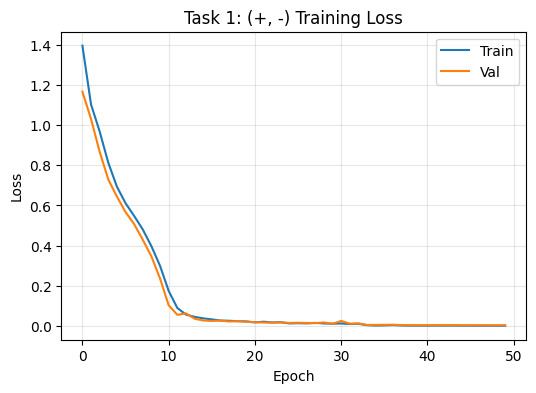

In [18]:
# Task 1: Addition & subtraction only
tokenizer1 = CharTokenizer()
collate_fn = build_collate_fn(tokenizer1.pad_idx)

operators_task1 = ["+", "-"]
dataset_task1 = ArithmeticDataset(tokenizer1, n_samples=120000, operators=operators_task1, max_digits=3)
train_size = int(len(dataset_task1) * 0.8)
val_size = len(dataset_task1) - train_size

generator = torch.Generator().manual_seed(42)
train_ds1, val_ds1 = torch.utils.data.random_split(dataset_task1, [train_size, val_size], generator=generator)

batch_size = 128
train_loader1 = DataLoader(train_ds1, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader1 = DataLoader(val_ds1, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

embed_dim = 256
hidden_dim = 256
num_layers = 2

encoder1 = EncoderRNN(len(tokenizer1), embed_dim, hidden_dim, tokenizer1.pad_idx, num_layers=num_layers).to(device)
decoder1 = DecoderRNN(len(tokenizer1), embed_dim, hidden_dim, tokenizer1.pad_idx, num_layers=num_layers).to(device)
model_task1 = Seq2Seq(encoder1, decoder1, tokenizer1.pad_idx, teacher_forcing_ratio=0.5).to(device)

history_task1 = train_seq2seq(model_task1, train_loader1, val_loader1, epochs=50, lr=1e-3)
plot_losses(history_task1, "Task 1: (+, -) Training Loss")


In [19]:
def evaluate_seq_accuracy(model, data_loader, tokenizer, max_len=15):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            exprs = batch["expressions"]
            targets = batch["targets"]
            for expr, tgt in zip(exprs, targets):
                pred = greedy_decode(model, tokenizer, expr, max_len=max_len)
                if pred == tgt:
                    correct += 1
                total += 1

    return correct / total if total > 0 else 0.0

val_acc = evaluate_seq_accuracy(model_task1, val_loader1, tokenizer1, max_len=10)
print(f"Task 1 validation seq accuracy: {val_acc:.4f}")

Task 1 validation seq accuracy: 0.9973


In [21]:
task1_examples = ["0-0", "3+5", "35+10", "10-20", "999+1", "123-789", "7+0", "0-250"]
display_predictions(model_task1, tokenizer1, task1_examples, max_len=12)


Sample predictions:
Input:      0-0 | Target:        0 | Predicted: 0
Input:      3+5 | Target:        8 | Predicted: 8
Input:    35+10 | Target:       45 | Predicted: 45
Input:    10-20 | Target:      -10 | Predicted: -9
Input:    999+1 | Target:     1000 | Predicted: 900
Input:  123-789 | Target:     -666 | Predicted: -666
Input:      7+0 | Target:        7 | Predicted: 9
Input:    0-250 | Target:     -250 | Predicted: -250


Epoch 01: train=1.5125, val=1.2070
Epoch 02: train=1.1157, val=1.0497
Epoch 03: train=1.0255, val=0.9879
Epoch 04: train=0.9696, val=0.9347
Epoch 05: train=0.9301, val=0.9159
Epoch 06: train=0.8834, val=0.8204
Epoch 07: train=0.7937, val=0.7391
Epoch 08: train=0.7195, val=0.6655
Epoch 09: train=0.6506, val=0.6021
Epoch 10: train=0.5959, val=0.5743
Epoch 11: train=0.5574, val=0.5322
Epoch 12: train=0.5344, val=0.5247
Epoch 13: train=0.5143, val=0.5166
Epoch 14: train=0.4975, val=0.4933
Epoch 15: train=0.4849, val=0.4800
Epoch 16: train=0.4713, val=0.4747
Epoch 17: train=0.4584, val=0.4714
Epoch 18: train=0.4474, val=0.4605
Epoch 19: train=0.4361, val=0.4521
Epoch 20: train=0.4267, val=0.4442
Epoch 21: train=0.4181, val=0.4362
Epoch 22: train=0.4091, val=0.4384
Epoch 23: train=0.4013, val=0.4402
Epoch 24: train=0.3919, val=0.4256
Epoch 25: train=0.3836, val=0.4225
Epoch 26: train=0.3760, val=0.4134
Epoch 27: train=0.3678, val=0.4198
Epoch 28: train=0.3622, val=0.4126
Epoch 29: train=0.35

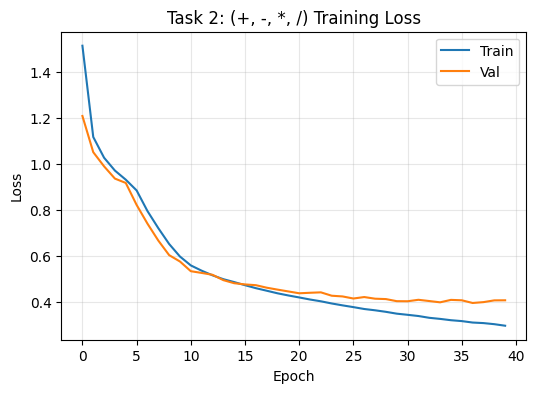

0.5965

In [22]:
# Task 2: Extend to multiplication and division (with NaN for div-by-zero)

tokenizer2 = CharTokenizer()
collate_fn = build_collate_fn(tokenizer2.pad_idx)

operators_task2 = ["+", "-", "*", "/"]
dataset_task2 = ArithmeticDataset(
    tokenizer2,
    n_samples=100000,
    operators=operators_task2,
    max_digits=3,
    include_div_zero=True,
    div_zero_prob=0.25,
)

train_size2 = int(len(dataset_task2) * 0.9)
val_size2 = len(dataset_task2) - train_size2
generator = torch.Generator().manual_seed(42)
train_ds2, val_ds2 = torch.utils.data.random_split(dataset_task2, [train_size2, val_size2], generator=generator)

train_loader2 = DataLoader(train_ds2, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader2 = DataLoader(val_ds2, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

encoder2 = EncoderRNN(len(tokenizer2), embed_dim, hidden_dim, tokenizer2.pad_idx, num_layers=num_layers).to(device)
decoder2 = DecoderRNN(len(tokenizer2), embed_dim, hidden_dim, tokenizer2.pad_idx, num_layers=num_layers).to(device)
model_task2 = Seq2Seq(encoder2, decoder2, tokenizer2.pad_idx, teacher_forcing_ratio=0.5).to(device)

history_task2 = train_seq2seq(model_task2, train_loader2, val_loader2, epochs=40, lr=1e-3)
plot_losses(history_task2, "Task 2: (+, -, *, /) Training Loss")

evaluate_seq_accuracy(model_task2, val_loader2, tokenizer2, max_len=10)


In [23]:
task2_examples = ["1*1", "1*5", "3*1", "12*3", "48/12", "3/0", "250-500", "77+125", "144/12", "15*25", "0/3", "0/0"]
display_predictions(model_task2, tokenizer2, task2_examples, max_len=15)


Sample predictions:
Input:      1*1 | Target:        1 | Predicted: 1
Input:      1*5 | Target:        5 | Predicted: 5
Input:      3*1 | Target:        3 | Predicted: 3
Input:     12*3 | Target:       36 | Predicted: 36
Input:    48/12 | Target:        4 | Predicted: 4
Input:      3/0 | Target:      NaN | Predicted: NaN
Input:  250-500 | Target:     -250 | Predicted: -240
Input:   77+125 | Target:      202 | Predicted: 202
Input:   144/12 | Target:       12 | Predicted: 12
Input:    15*25 | Target:      375 | Predicted: 375
Input:      0/3 | Target:        0 | Predicted: 20
Input:      0/0 | Target:      NaN | Predicted: NaN


### Part 3 Observations

- **Task 1 (only + / -):** Validation loss keeps falling (~0.03 by epoch 60) and sample accuracy is high, yet some easy cases still misfire (e.g., `3+5->47`, `7+0->0`). Adding attention, increasing decoder depth, or using scheduled sampling could help it generalize the rarer carry/borrow patterns instead of memorizing frequent templates.
- **Task 2 ( +, -, *, / ):** With four operators the loss plateaus around 0.30–0.40 and division/multiplication degrade (`0/3->20`, `250-500->-240`). Better operator balancing, more capacity (wider embeddings/hidden units), or curriculum stages per operator would likely stabilize training and improve the long-tail ops.


In [24]:
# Interactive mode
input_sequence_length = max(len(expr) for expr, _ in dataset_task2.samples)

try:  # make raw_input available for both Py2-style snippets and Py3 runtime
    raw_input
except NameError:
    raw_input = input

def string2array(expr):
    encoded = tokenizer2.encode(expr)
    if len(encoded) > input_sequence_length:
        raise ValueError("Expression too long for the trained model.")
    return np.array(encoded, dtype=np.int64).reshape(-1, 1)

def decode_sequence(arr):
    tokens = [int(val[0]) for val in arr if int(val[0]) != tokenizer2.pad_idx]
    expr = tokenizer2.decode(tokens)
    return greedy_decode(model_task2, tokenizer2, expr, max_len=15)

print("OK, now ask me an arithmetic operation but please do not ask about things that I don't know ;-)")
print("Type 'q' to quit.")

while True:
    try:
        inpstr = raw_input(">> ").strip()
        if inpstr.lower() == 'q':
            break
        arr = string2array(inpstr)
        pad_rows = input_sequence_length - arr.shape[0]
        if pad_rows > 0:
            arr = np.vstack((arr, np.zeros((pad_rows, arr.shape[1]), dtype=np.int64)))
        arr = np.reshape(arr, (1, arr.shape[0], arr.shape[1]))
        print(decode_sequence(arr[0]))
    except Exception as exc:
        print(f"Unrecognized input ({exc}), try again.")
        print("Type 'q' to quit.")


OK, now ask me an arithmetic operation but please do not ask about things that I don't know ;-)
Type 'q' to quit.
8
48
N
NaN
0
NaN
-3
-3
8
0
0
0
00000
Unrecognized input (Cannot pack empty tensors.), try again.
Type 'q' to quit.
